# TIG Weight Visualisation — Analytical GPS Model

Loads pre-computed Task Interaction Graph (TIG) edge weights from disk and visualises them across all four delta methods.

To switch scenario:
   1. Set SCENARIO to any subdirectory of  results/analytical/TIG/
   2. Set delta_method to the active method for pair ranking / partitioning
   3. Re-run all cells (no heavy computation — just file I/O)

## Scenario Selection

In [37]:
from pathlib import Path
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Scenario selection ────────────────────────────────────────────────────────
SCENARIO     = "M4N3_B_striped"
delta_method = "sii_marginalised"   # active method for pair ranking / partitioning
TIG_DIR      = Path(f"results/analytical/TIG/{SCENARIO}")
METHODS      = ["cosine", "sii_marginalised", "sii_null", "sobol"]

# ── Load config stored alongside results ─────────────────────────────────────
with open(TIG_DIR / "config.yaml") as f:
    cfg = yaml.safe_load(f)

N   = cfg["system"]["N"]
M   = cfg["system"]["M"]
L   = cfg["system"]["L"]
dlt = cfg["delta"]

f_node = {n["id"]: n["f"] for n in cfg["nodes"]}

services  = {}
workflows = {}
for wf in cfg["workflows"]:
    wid = wf["id"]
    workflows[wid] = {"lambda": wf["lambda"], "services": []}
    for stage, svc in enumerate(wf["services"]):
        sid = svc["id"]
        services[sid] = {
            "node":   svc["node"],   "workflow": wid,
            "stage":  stage,         "r_base":   svc["replicas_baseline"],
            "A":      svc["action_space"],
        }
        workflows[wid]["services"].append(sid)

node_services = {n: [] for n in range(N)}
for sid, svc in services.items():
    node_services[svc["node"]].append(sid)

C_max  = cfg["tig"]["C_max"]
rho    = cfg["tig"]["rho"]
w_drop = cfg["tig"]["kpi_weights"]["drop_rate"]
w_util = cfg["tig"]["kpi_weights"]["utilization"]

kpi_names   = [f"D_wf{w}/λ" for w in range(M)] + [f"u_node{n}" for n in range(N)]
kpi_weights = [w_drop / M] * M + [w_util / N] * N
omega       = np.array(kpi_weights)

task_ids   = sorted(services.keys())
task_names = [f"t{i}(s{i})" for i in task_ids]
n_tasks    = len(task_ids)
n_kpis     = len(kpi_names)

print(f"Scenario : {SCENARIO}")
print(f"TIG dir  : {TIG_DIR}")
print(f"Nodes={N}  Workflows={M}  L={L}  δ={dlt}")
print(f"KPIs: {kpi_names}")
print(f"KPI weights: {[round(w, 3) for w in kpi_weights]}")
print(f"C_max={C_max}  ρ={rho}")
print(f"\n► Active delta_method: '{delta_method}'")

Scenario : M4N3_B_striped
TIG dir  : results/analytical/TIG/M4N3_B_striped
Nodes=3  Workflows=4  L=10  δ=5
KPIs: ['D_wf0/λ', 'D_wf1/λ', 'D_wf2/λ', 'D_wf3/λ', 'u_node0', 'u_node1', 'u_node2']
KPI weights: [0.125, 0.125, 0.125, 0.125, 0.167, 0.167, 0.167]
C_max=100  ρ=0.1

► Active delta_method: 'sii_marginalised'


## Load TIG from disk

Reads the pre-computed matrices produced by `compute_analytical_tig.py` for every delta method.

In [38]:
print(f"Loading TIG: {TIG_DIR}\n")
all_res = {}
all_W   = {}

for method in METHODS:
    d = TIG_DIR / method
    if not d.exists():
        print(f"  ✗ {method:<20s}  not found — skipping")
        continue
    indiv  = pd.read_csv(d / "indiv.csv",  index_col=0).values
    F_pull = pd.read_csv(d / "F_pull.csv", index_col=0).values
    W      = pd.read_csv(d / "W.csv",      index_col=0).values
    all_res[method] = {"indiv": indiv, "F_pull": F_pull}
    all_W[method]   = W
    print(f"  ✓ {method:<20s}  W shape = {W.shape}")

_first = next(m for m in METHODS if m in all_W)
F_push = pd.read_csv(TIG_DIR / _first / "F_push.csv", index_col=0).values

W_active = all_W[delta_method]

for method in all_res:
    assert np.allclose(all_res[method]["F_pull"], all_res[method]["F_pull"].T)
assert np.allclose(W_active, W_active.T)
print(f"\n✓ All F_pull matrices symmetric")
print(f"► Active: '{delta_method}'")

Loading TIG: results/analytical/TIG/M4N3_B_striped

  ✓ cosine                W shape = (8, 8)
  ✓ sii_marginalised      W shape = (8, 8)
  ✓ sii_null              W shape = (8, 8)
  ✓ sobol                 W shape = (8, 8)

✓ All F_pull matrices symmetric
► Active: 'sii_marginalised'


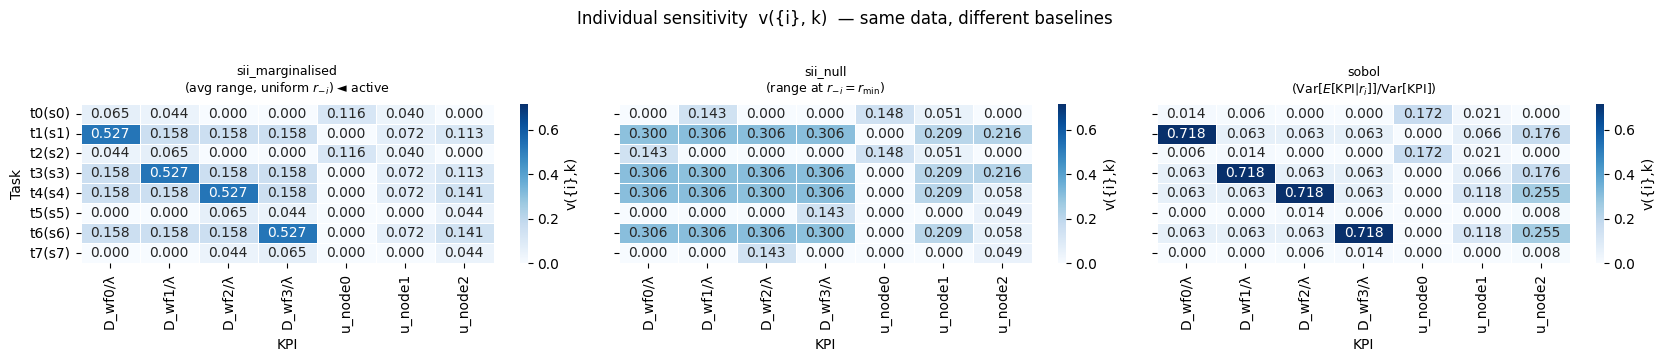

(cosine uses the same v({i},k) as sii_marginalised)


In [39]:
# ── Individual sensitivity v({i}, k) across methods ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 3.5), sharey=True)
plot_methods = ["sii_marginalised", "sii_null", "sobol"]
titles = {
    "sii_marginalised": "sii_marginalised\n(avg range, uniform $r_{-i}$)",
    "sii_null":         "sii_null\n(range at $r_{-i}=r_{\\min}$)",
    "sobol":            "sobol\n($\\mathrm{Var}[E[\\mathrm{KPI}|r_i]] / \\mathrm{Var}[\\mathrm{KPI}]$)",
}
# cosine uses same indiv as sii_marginalised — shown once
vmax = max(all_res[m]["indiv"].max() for m in plot_methods)
for ax, m in zip(axes, plot_methods):
    df = pd.DataFrame(all_res[m]["indiv"], index=task_names, columns=kpi_names)
    star = " ◄ active" if m == delta_method else ""
    sns.heatmap(df, annot=True, fmt=".3f", cmap="Blues",
                vmin=0, vmax=vmax, linewidths=0.5, linecolor="white",
                cbar_kws={"label": "v({i},k)"}, ax=ax)
    ax.set_title(titles[m] + star, pad=8, fontsize=9)
    ax.set_xlabel("KPI"); ax.set_ylabel("")

axes[0].set_ylabel("Task")
plt.suptitle("Individual sensitivity  v({i}, k)  — same data, different baselines", y=1.02)
plt.tight_layout()
plt.show()

print("(cosine uses the same v({i},k) as sii_marginalised)")

## Step 4 — F_pull (all four methods)

`cosine` builds a per-task footprint vector $\vec{c}_i = \omega \cdot v(\{i\})$ and uses cosine similarity.  
The three SII methods aggregate the pairwise interaction $I(i,j,k)$ directly, then normalise to $[0,1]$.

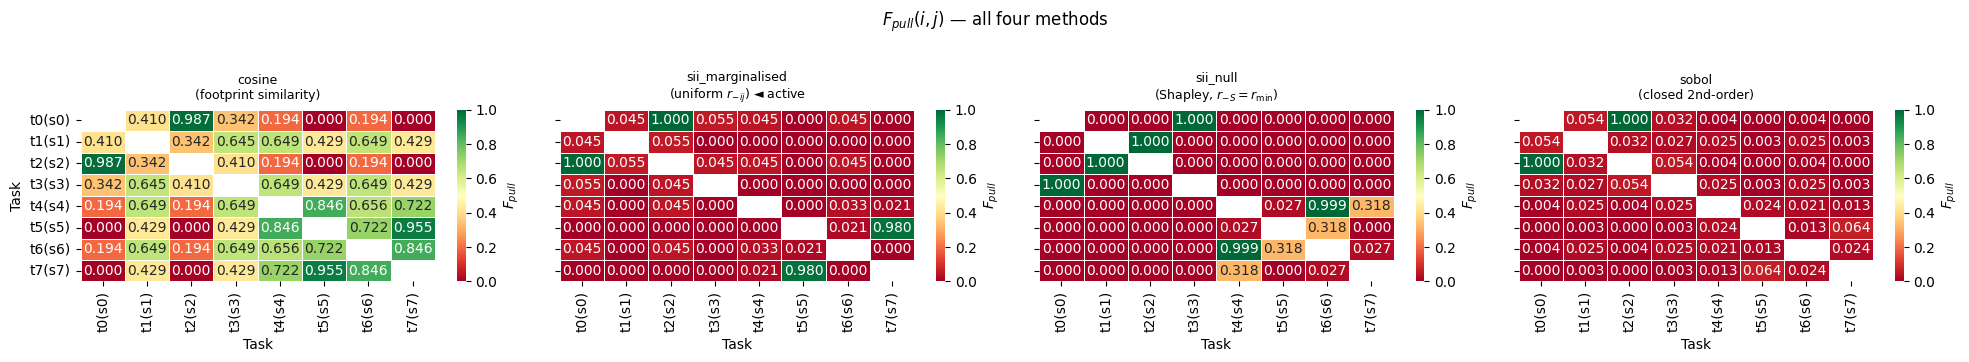

Pair ranking — active method 'sii_marginalised':

  t0(s0) ↔ t2(s2)   F_pull=1.0000   [same-node]
  t5(s5) ↔ t7(s7)   F_pull=0.9795   [same-node]
  t1(s1) ↔ t2(s2)   F_pull=0.0547   [cross-node]
  t0(s0) ↔ t3(s3)   F_pull=0.0547   [cross-node]
  t2(s2) ↔ t6(s6)   F_pull=0.0453   [cross-node]
  t2(s2) ↔ t4(s4)   F_pull=0.0453   [cross-node]
  t0(s0) ↔ t6(s6)   F_pull=0.0453   [cross-node]
  t0(s0) ↔ t4(s4)   F_pull=0.0453   [cross-node]
  t2(s2) ↔ t3(s3)   F_pull=0.0451   [cross-node]
  t0(s0) ↔ t1(s1)   F_pull=0.0451   [cross-node]
  t4(s4) ↔ t6(s6)   F_pull=0.0334   [same-node]
  t5(s5) ↔ t6(s6)   F_pull=0.0213   [cross-node]
  t4(s4) ↔ t7(s7)   F_pull=0.0213   [cross-node]
  t2(s2) ↔ t5(s5)   F_pull=0.0000   [cross-node]
  t2(s2) ↔ t7(s7)   F_pull=0.0000   [cross-node]
  t1(s1) ↔ t5(s5)   F_pull=0.0000   [cross-node]
  t1(s1) ↔ t7(s7)   F_pull=0.0000   [cross-node]
  t3(s3) ↔ t5(s5)   F_pull=0.0000   [cross-node]
  t3(s3) ↔ t7(s7)   F_pull=0.0000   [cross-node]
  t0(s0) ↔ t5(s5)   F_

In [40]:
fig, axes = plt.subplots(1, 4, figsize=(20, 3.5), sharey=True)
mask = np.eye(n_tasks, dtype=bool)
method_labels = {
    "cosine":          "cosine\n(footprint similarity)",
    "sii_marginalised":"sii_marginalised\n(uniform $r_{-ij}$)",
    "sii_null":        "sii_null\n(Shapley, $r_{-S}=r_{\\min}$)",
    "sobol":           "sobol\n(closed 2nd-order)",
}

for ax, m in zip(axes, METHODS):
    fp = pd.DataFrame(all_res[m]["F_pull"], index=task_names, columns=task_names)
    star = " ◄ active" if m == delta_method else ""
    sns.heatmap(fp, annot=True, fmt=".3f", cmap="RdYlGn",
                vmin=0, vmax=1, mask=mask,
                linewidths=0.5, linecolor="white",
                cbar_kws={"label": "$F_{pull}$"}, ax=ax)
    ax.set_title(method_labels[m] + star, pad=8, fontsize=9)
    ax.set_xlabel("Task"); ax.set_ylabel("")

axes[0].set_ylabel("Task")
plt.suptitle("$F_{pull}(i,j)$ — all four methods", y=1.02)
plt.tight_layout()
plt.show()

# ── Pair ranking for active method ────────────────────────────────────────────
fp_active = all_res[delta_method]["F_pull"]
pairs = [(task_names[i], task_names[j], fp_active[i,j])
         for i in range(n_tasks) for j in range(i+1, n_tasks)]
pairs.sort(key=lambda x: -x[2])
print(f"Pair ranking — active method '{delta_method}':\n")
for t1, t2, fp in pairs:
    ni = services[int(t1[1])]["node"]; nj = services[int(t2[1])]["node"]
    tag = "same-node" if ni == nj else "cross-node"
    print(f"  {t1} ↔ {t2}   F_pull={fp:.4f}   [{tag}]")

## Steps 5 & 6 — F_push and W_{i,j}

### F_push: complexity penalty

$$F_{\text{push}}(i,j) = \sigma\!\left(\rho \cdot \bigl(C(i,j) - C_{\max}\bigr)\right), \qquad C(i,j) = |\mathcal{A}_i| \times |\mathcal{A}_j|$$

$C(i,j)$ is the joint decision-space size of the pair. The logistic maps it onto $(0,1)$: when $C(i,j) \ll C_{\max}$ the penalty is near zero (no push against co-assignment); when $C(i,j) \gg C_{\max}$ it approaches 1 (strong push). $\rho$ controls how sharply the transition happens around $C_{\max}$.

For this system every task has $|\mathcal{A}_i| = 4$, so all pairs have $C(i,j) = 16 \ll C_{\max} = 100$. The push is negligible for pairs. The constraint becomes binding only when a partitioning algorithm considers groups of 4 tasks ($4^4 = 256 > C_{\max}$), which happens *downstream* — the pairwise TIG weights capture the pull, and the partitioner respects the complexity budget.

---

### W_{i,j}: final TIG edge weight

$$W_{i,j} = F_{\text{pull}}(i,j) \cdot \bigl(1 - F_{\text{push}}(i,j)\bigr) \in [0,1]$$

$F_{\text{push}}$ acts as a discount factor: it suppresses high-pull pairs whose joint complexity would exceed the agent's budget. High $W$ → tasks should be co-assigned; low $W$ → cut this edge in the graph partition.

In [41]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

A_size = len(list(services.values())[0]["A"])
print(f"F_push (any pair, |A|²={A_size**2}): {sigmoid(rho * (A_size**2 - C_max)):.6f}  — negligible\n")
print(f"Active W matrix  ('{delta_method}'):\n")
display(pd.DataFrame(W_active, index=task_names, columns=task_names).round(4))

F_push (any pair, |A|²=16): 0.000225  — negligible

Active W matrix  ('sii_marginalised'):



,t0(s0),t1(s1),t2(s2),t3(s3),t4(s4),t5(s5),t6(s6),t7(s7)
t0(s0),0.0000,0.0451,0.9998,0.0547,0.0453,0.0000,0.0453,0.0000
t1(s1),0.0451,0.0000,0.0547,0.0000,0.0000,0.0000,0.0000,0.0000
t2(s2),0.9998,0.0547,0.0000,0.0451,0.0453,0.0000,0.0453,0.0000
t3(s3),0.0547,0.0000,0.0451,0.0000,0.0000,0.0000,0.0000,0.0000
t4(s4),0.0453,0.0000,0.0453,0.0000,0.0000,0.0000,0.0334,0.0213
t5(s5),0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0213,0.9793
t6(s6),0.0453,0.0000,0.0453,0.0000,0.0334,0.0213,0.0000,0.0000
t7(s7),0.0000,0.0000,0.0000,0.0000,0.0213,0.9793,0.0000,0.0000


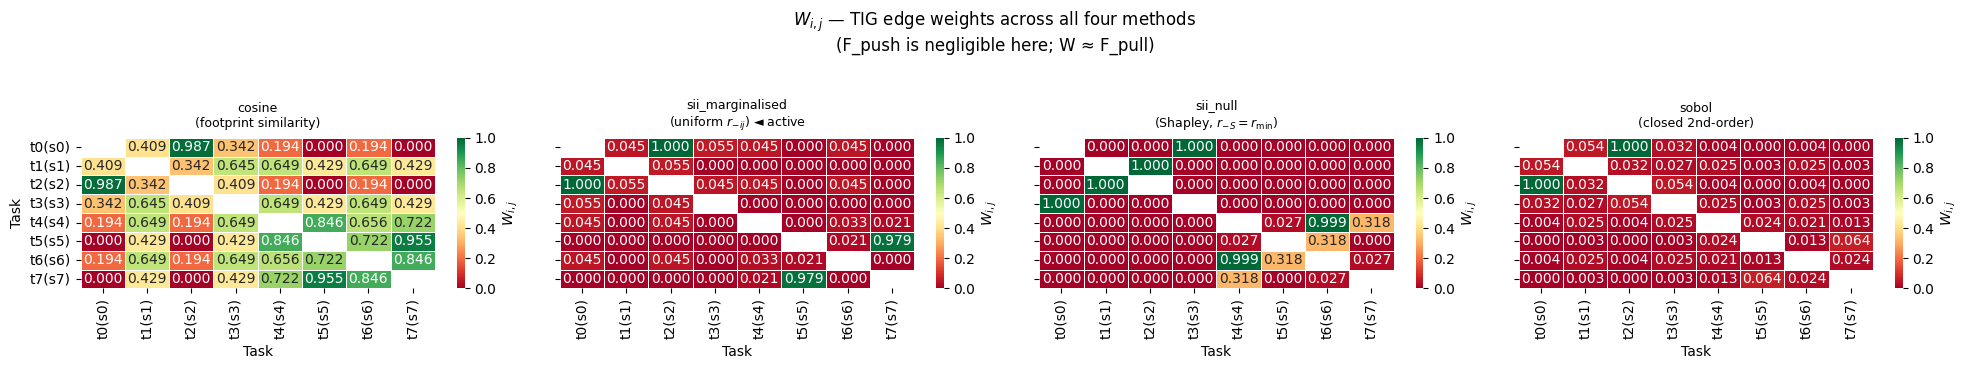

Same-node vs cross-node gap in W  (higher gap → cleaner signal):

  Method                  same-node avg   cross-node avg   gap
  --------------------------------------------------------------
  cosine                  0.7299          0.3565           0.3734
  sii_marginalised        0.2516          0.0212           0.2304 ◄
  sii_null                0.1249          0.1345           -0.0096
  sobol                   0.1513          0.0137           0.1376


In [42]:
# ── W comparison — all four methods ──────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 3.5), sharey=True)
mask = np.eye(n_tasks, dtype=bool)
vmin_W = min(all_W[m][~mask].min() for m in METHODS)
vmax_W = 1.0

for ax, m in zip(axes, METHODS):
    df = pd.DataFrame(all_W[m], index=task_names, columns=task_names)
    star = " ◄ active" if m == delta_method else ""
    sns.heatmap(df, annot=True, fmt=".3f", cmap="RdYlGn",
                vmin=vmin_W, vmax=vmax_W, mask=mask,
                linewidths=0.5, linecolor="white",
                cbar_kws={"label": "$W_{i,j}$"}, ax=ax)
    ax.set_title(method_labels[m] + star, pad=8, fontsize=9)
    ax.set_xlabel("Task"); ax.set_ylabel("")

axes[0].set_ylabel("Task")
plt.suptitle("$W_{i,j}$ — TIG edge weights across all four methods\n"
             "(F_push is negligible here; W ≈ F_pull)", y=1.04)
plt.tight_layout()
plt.show()

# ── Gap: same-node vs cross-node pairs across methods ────────────────────────
print("Same-node vs cross-node gap in W  (higher gap → cleaner signal):\n")
print(f"  {'Method':<22}  same-node avg   cross-node avg   gap")
print("  " + "-"*62)
for m in METHODS:
    W = all_W[m]
    sn = np.mean([W[i,j] for i in range(n_tasks) for j in range(n_tasks)
                  if i != j and services[task_ids[i]]["node"] == services[task_ids[j]]["node"]])
    cn = np.mean([W[i,j] for i in range(n_tasks) for j in range(n_tasks)
                  if i != j and services[task_ids[i]]["node"] != services[task_ids[j]]["node"]])
    star = " ◄" if m == delta_method else ""
    print(f"  {m:<22}  {sn:.4f}          {cn:.4f}           {sn-cn:.4f}{star}")

## Step 7 — Graph Partitioning

The weight matrix $W$ is treated as the adjacency of an undirected Task Interaction Graph. Partitioning it into agent groups assigns each task to exactly one agent so that:

- **High-$W$ edges are kept within groups** (tasks that need coordination stay together).
- **No group's joint action space exceeds $C_{\max}$** (tractability constraint).

Three algorithms are available via `partitioning.algorithm` in the config:

| Algorithm | Description | `n_agents` |
|-----------|-------------|------------|
| `greedy_modularity` | Louvain-style greedy modularity maximisation | inferred |
| `spectral` | Eigen-decomposition of $W$; k-means on eigenvectors | required |
| `kernighan_lin` | Heuristic bisection minimising weighted cut | must be 2 |

**Expected result for Mapping S — Striped:** TIG should discover node-aligned groups $\{s_0, s_2\}$ and $\{s_1, s_3\}$, matching physical node co-location — even though per-workflow assignment would give $\{s_0, s_1\}$ and $\{s_2, s_3\}$.

In [43]:
import networkx as nx
from networkx.algorithms.community import (
    greedy_modularity_communities,
    kernighan_lin_bisection,
)
from sklearn.cluster import SpectralClustering

In [44]:
TIG_ALGOS  = ["greedy_modularity", "spectral", "kernighan_lin"]
TOPO_ALGOS = ["all_in_one", "all_separate", "per_node", "per_workflow"]
ALL_ALGOS  = TIG_ALGOS + TOPO_ALGOS

# ── Partitioning settings ─────────────────────────────────────────────────────
algorithm = "spectral"
n_agents  = 3

assert algorithm in ALL_ALGOS, f"algorithm must be one of {ALL_ALGOS}"
if algorithm == "kernighan_lin":
    assert n_agents == 2, "kernighan_lin only supports n_agents=2"

# ── Node-aligned reference partition ─────────────────────────────────────────
node_to_tidx = {}
for idx, sid in enumerate(task_ids):
    node_to_tidx.setdefault(services[sid]["node"], []).append(idx)
node_aligned_partition = {frozenset(v) for v in node_to_tidx.values()}

# ── Helper ────────────────────────────────────────────────────────────────────
def run_partition(W, algo, n_ag):
    n = len(W)
    G = nx.from_numpy_array(W)

    if algo == "greedy_modularity":
        comms = list(greedy_modularity_communities(G, weight="weight"))
    elif algo == "spectral":
        sc  = SpectralClustering(n_clusters=n_ag, affinity="precomputed",
                                 assign_labels="kmeans", random_state=0)
        lbl = sc.fit_predict(W)
        comms = [[i for i, l in enumerate(lbl) if l == a] for a in range(n_ag)]
    elif algo == "kernighan_lin":
        a, b  = kernighan_lin_bisection(G, weight="weight")
        comms = [list(a), list(b)]
    elif algo == "all_in_one":
        comms = [list(range(n))]
    elif algo == "all_separate":
        comms = [[i] for i in range(n)]
    elif algo == "per_node":
        groups = {}
        for idx, sid in enumerate(task_ids):
            groups.setdefault(services[sid]["node"], []).append(idx)
        comms = list(groups.values())
    elif algo == "per_workflow":
        groups = {}
        for idx, sid in enumerate(task_ids):
            groups.setdefault(services[sid]["workflow"], []).append(idx)
        comms = list(groups.values())

    return [sorted(c) for c in sorted(comms, key=lambda c: min(c))]

# ── Run active partition ──────────────────────────────────────────────────────
communities   = run_partition(W_active, algorithm, n_agents)
task_to_agent = {t: a for a, grp in enumerate(communities) for t in grp}

if len(communities) == 1 and algorithm != "all_in_one":
    print(f"⚠  '{algorithm}' merged all tasks into one community — try 'spectral' or 'kernighan_lin'.\n")

# ── Complexity and assignment report ─────────────────────────────────────────
print(f"Algorithm : {algorithm}  |  W source: {delta_method}  |  Groups found: {len(communities)}\n")
for agent_id, group in enumerate(communities):
    action_sizes = [len(services[task_ids[t]]["A"]) for t in group]
    joint_space  = 1
    for s in action_sizes: joint_space *= s
    flag = "✓" if joint_space <= C_max else f"✗ EXCEEDS C_max={C_max}"
    print(f"  Agent {agent_id}: {[task_names[t] for t in group]}")
    print(f"           nodes={[services[task_ids[t]]['node'] for t in group]}"
          f"  workflows={[services[task_ids[t]]['workflow'] for t in group]}")
    print(f"           |A|^k = {'×'.join(str(s) for s in action_sizes)} = {joint_space}  {flag}\n")

# ── Cut quality ───────────────────────────────────────────────────────────────
within = [W_active[i,j] for i in range(n_tasks) for j in range(i+1,n_tasks)
          if task_to_agent[i] == task_to_agent[j]]
cut    = [W_active[i,j] for i in range(n_tasks) for j in range(i+1,n_tasks)
          if task_to_agent[i] != task_to_agent[j]]
if within: print(f"Within-group W : mean={np.mean(within):.4f}  min={np.min(within):.4f}")
if cut:    print(f"Cut-edge     W : mean={np.mean(cut):.4f}  max={np.max(cut):.4f}")

# ── Reference check ───────────────────────────────────────────────────────────
found = {frozenset(c) for c in communities}
match = found == node_aligned_partition
ref   = sorted([sorted(g) for g in node_aligned_partition], key=lambda g: min(g))
print(f"\nNode-aligned ref : {[[task_names[t] for t in g] for g in ref]}")
print(f"Found            : {[[task_names[t] for t in c] for c in communities]}")
print(f"Matches ref      : {'✓' if match else '✗'}")

Algorithm : spectral  |  W source: sii_marginalised  |  Groups found: 3

  Agent 0: ['t0(s0)', 't1(s1)', 't2(s2)', 't3(s3)']
           nodes=[0, 1, 0, 1]  workflows=[0, 0, 1, 1]
           |A|^k = 4×4×4×4 = 256  ✗ EXCEEDS C_max=100

  Agent 1: ['t4(s4)', 't6(s6)']
           nodes=[1, 1]  workflows=[2, 3]
           |A|^k = 4×4 = 16  ✓

  Agent 2: ['t5(s5)', 't7(s7)']
           nodes=[2, 2]  workflows=[2, 3]
           |A|^k = 4×4 = 16  ✓

Within-group W : mean=0.2765  min=0.0000
Cut-edge     W : mean=0.0112  max=0.0453

Node-aligned ref : [['t0(s0)', 't2(s2)'], ['t1(s1)', 't3(s3)', 't4(s4)', 't6(s6)'], ['t5(s5)', 't7(s7)']]
Found            : [['t0(s0)', 't1(s1)', 't2(s2)', 't3(s3)'], ['t4(s4)', 't6(s6)'], ['t5(s5)', 't7(s7)']]
Matches ref      : ✗


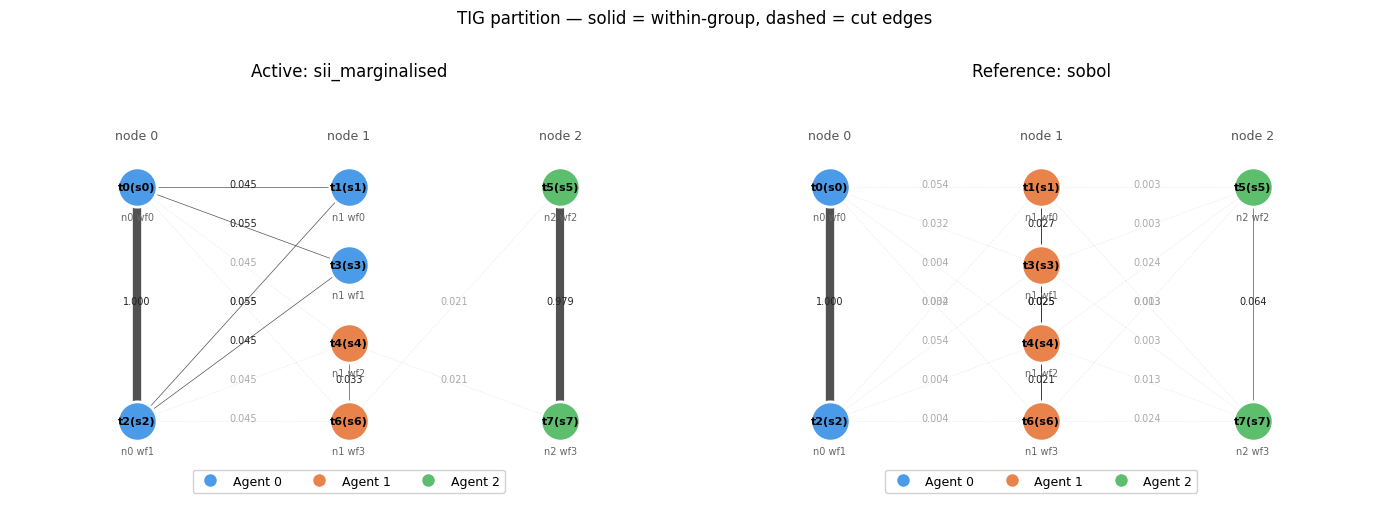

Partition correctness  (ref = node-aligned)

  algorithm             delta_method          ok?  groups
  --------------------------------------------------------------------------------
  greedy_modularity     cosine                ✗    [['t0(s0)', 't1(s1)', 't2(s2)', 't3(s3)'], ['t4(s4)', 't5(s5)', 't6(s6)', 't7(s7)']]
  greedy_modularity     sii_marginalised      ✗    [['t0(s0)', 't1(s1)', 't2(s2)', 't3(s3)', 't4(s4)', 't6(s6)'], ['t5(s5)', 't7(s7)']]
  greedy_modularity     sii_null              ✗    [['t0(s0)', 't3(s3)'], ['t1(s1)', 't2(s2)'], ['t4(s4)', 't5(s5)', 't6(s6)', 't7(s7)']
  greedy_modularity     sobol                 ✗    [['t0(s0)', 't2(s2)'], ['t1(s1)', 't3(s3)', 't4(s4)', 't5(s5)', 't6(s6)', 't7(s7)']]

  spectral              cosine                ✗    [['t0(s0)', 't2(s2)'], ['t1(s1)', 't3(s3)'], ['t4(s4)', 't5(s5)', 't6(s6)', 't7(s7)']
  spectral              sii_marginalised      ✗    [['t0(s0)', 't1(s1)', 't2(s2)', 't3(s3)'], ['t4(s4)', 't6(s6)'], ['t5(s5)', 't7(

/Users/gtzanettis/Documents/Projects/agent-task-distribution/.venv/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


In [45]:
# ── Dynamic node layout: tasks grouped by physical node in columns ────────────
agent_colors = ["#4C9BE8", "#E8834C", "#5DBE6E", "#B07ED4", "#E8D44C", "#9BE84C"]

def make_positions(task_ids, services, node_to_tidx):
    pos = {}
    nodes_sorted = sorted(node_to_tidx.keys())
    x_step = 1.0 / max(len(nodes_sorted) - 1, 1)
    for col, nd in enumerate(nodes_sorted):
        tidxs  = node_to_tidx[nd]
        y_vals = np.linspace(0.6, -0.6, len(tidxs)) if len(tidxs) > 1 else [0.0]
        for row, tidx in enumerate(tidxs):
            pos[tidx] = (col * x_step, y_vals[row])
    return pos

pos          = make_positions(task_ids, services, node_to_tidx)
nodes_sorted = sorted(node_to_tidx.keys())
x_step       = 1.0 / max(len(nodes_sorted) - 1, 1)

def draw_tig(ax, W_plot, t2a, title):
    node_colors = [agent_colors[t2a[t] % len(agent_colors)] for t in range(n_tasks)]
    for i in range(n_tasks):
        for j in range(i + 1, n_tasks):
            w = W_plot[i, j]
            if w < 1e-6:
                continue
            same = t2a[i] == t2a[j]
            ax.plot([pos[i][0], pos[j][0]], [pos[i][1], pos[j][1]],
                    linewidth=max(w * 6, 0.5),
                    alpha=0.85 if same else 0.25,
                    color="#333333" if same else "#BBBBBB",
                    linestyle="-" if same else "--", zorder=1)
            mid = ((pos[i][0] + pos[j][0]) / 2, (pos[i][1] + pos[j][1]) / 2)
            ax.text(mid[0], mid[1], f"{w:.3f}", fontsize=7, ha="center",
                    color="#222222" if same else "#AAAAAA", zorder=3)
    for t in range(n_tasks):
        x, y = pos[t]
        svc  = services[task_ids[t]]
        ax.scatter(x, y, s=800, color=node_colors[t], zorder=4,
                   edgecolors="white", linewidths=2)
        ax.text(x, y, task_names[t], ha="center", va="center",
                fontsize=8, fontweight="bold", zorder=5)
        ax.text(x, y - 0.17, f"n{svc['node']} wf{svc['workflow']}",
                ha="center", fontsize=7, color="#666666", zorder=5)
    for col, nd in enumerate(nodes_sorted):
        ax.text(col * x_step, 0.85, f"node {nd}", ha="center",
                fontsize=9, color="#555555")
    handles = [plt.Line2D([0], [0], marker='o', color='w',
                           markerfacecolor=agent_colors[a % len(agent_colors)],
                           markersize=10, label=f"Agent {a}")
               for a in sorted(set(t2a.values()))]
    ax.legend(handles=handles, loc="lower center", ncol=len(handles),
              framealpha=0.9, fontsize=9)
    ax.set_xlim(-0.3, (len(nodes_sorted) - 1) * x_step + 0.3)
    ax.set_ylim(-1.0, 1.1)
    ax.axis("off")
    ax.set_title(title, pad=10)

# ── Figure: active W ─────────────────────────────────────────────────────────
ref_method = "sobol" if delta_method == "sii_marginalised" else "sii_marginalised"
W_ref      = all_W[ref_method]
comms_ref  = run_partition(W_ref, algorithm, n_agents)
t2a_ref    = {t: a for a, grp in enumerate(comms_ref) for t in grp}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
draw_tig(axes[0], W_active, task_to_agent, f"Active: {delta_method}")
draw_tig(axes[1], W_ref,    t2a_ref,       f"Reference: {ref_method}")
plt.suptitle("TIG partition — solid = within-group, dashed = cut edges", y=1.01)
plt.tight_layout()
plt.show()

# ── Full comparison table ─────────────────────────────────────────────────────
print(f"Partition correctness  (ref = node-aligned)\n")
print(f"  {'algorithm':<20}  {'delta_method':<20}  ok?  groups")
print("  " + "-"*80)

for algo in TIG_ALGOS:
    for meth in [m for m in METHODS if m in all_W]:
        try:
            comms    = run_partition(all_W[meth], algo, n_agents)
            match    = {frozenset(c) for c in comms} == node_aligned_partition
            ok       = "✓" if match else ("⚠" if len(comms) == 1 else "✗")
            part_str = str([[task_names[t] for t in c] for c in comms])
        except Exception as e:
            ok = "err"; part_str = str(e)[:50]
        star = " ◄" if (algo == algorithm and meth == delta_method) else ""
        print(f"  {algo:<20}  {meth:<20}  {ok}    {part_str[:85]}{star}")
    print()

print(f"  {'Topology baselines':-<80}")
for algo in TOPO_ALGOS:
    comms    = run_partition(W_active, algo, n_agents)
    match    = {frozenset(c) for c in comms} == node_aligned_partition
    ok       = "✓" if match else "✗"
    part_str = str([[task_names[t] for t in c] for c in comms])
    star     = " ◄" if algo == algorithm else ""
    print(f"  {algo:<20}  {'(topology)':<20}  {ok}    {part_str[:85]}{star}")

## Step 8 — Simulator Baseline Run

Translates the analytical config into the discrete-event simulator and runs it with
`r_base` replicas for every service (no RL — fixed allocation).

- **Dropped packets** = traces that time out (`status ≠ 1`) — analogous to the GPS drop rate `D_w/λ`.
- **CPU utilisation** = avg running threads / `r_base_total` per node — matches the GPS formula `u_n` when `node.cpu = Σ r_base`.

`PassiveRecorder` pattern from `queueing_game_simulator.ipynb`: dedup callbacks by sim time, forward-hook syncs `t_ref`.

In [46]:
import sys
sys.path.insert(0, "workflow_simulator")

from simulator.application import Application, LOADMAX
from simulator.infrastructure import Node
from simulator.simulation import Simulation

TASK_LOAD = int(2 * 0.1 * LOADMAX)   # 1400 ops/req  (entry + exit subtasks)

# Scale GPS parameters to simulator units so capacity formulas align exactly.
# GPS: capacity = r * (f_n - dlt*R_n) / (L * R_n)
# sim: capacity = r * (FREQ - OVERHEAD*R_n) / (TASK_LOAD * R_n)  (with cpu=1)
# Equality holds when FREQ/TASK_LOAD = f_n/L and OVERHEAD/TASK_LOAD = dlt/L.
FREQ     = int(f_node[0] * TASK_LOAD / L)   # 140 000 op/s
OVERHEAD = int(dlt       * TASK_LOAD / L)   # 700 op/s per running thread

SIM_TIMEOUT    = 1.0       # seconds — overloaded-node traces that queue > 1 s time out
SIM_ITERATIONS = 200_000
EVAL_INTERVAL  = 5.0

# ── Translate config into simulator topology ──────────────────────────────────
sim_nodes = {
    n: Node(id=n, cpu=1, ram=8, freq=FREQ, thread_cpu_overhead=OVERHEAD)
    for n in range(N)
}

topology = {
    "n_services": len(task_ids),
    "workflows": [
        {
            "id":           wid,
            "root_service": wf["services"][0],
            "edges":        list(zip(wf["services"][:-1], wf["services"][1:])),
            "lam":          wf["lambda"],
        }
        for wid, wf in workflows.items()
    ],
}

app_sim = Application(topology=topology)
app_sim.deploy_services({sid: sim_nodes[svc["node"]] for sid, svc in services.items()})
for sid, svc in services.items():
    app_sim.services[sid].threads = svc["r_base"]

print(f"TASK_LOAD={TASK_LOAD}  FREQ={FREQ}  OVERHEAD={OVERHEAD}")
print("\nService → node mapping:")
for sid, svc in services.items():
    print(f"  s{sid} → node{svc['node']}  threads={svc['r_base']}  wf={svc['workflow']}")

# ── PassiveRecorder — same pattern as queueing_game_simulator.ipynb ───────────
sim_eval_records = []

class PassiveRecorder:
    def __init__(self, t_ref):
        self._t    = t_ref
        self._seen = set()

    def on_eval(self, service_idx, service, accumulated, instant):
        key = (round(self._t[0], 6), service_idx)
        if key in self._seen:
            return None
        self._seen.add(key)
        svc_instant = instant["services"][service_idx]
        sim_eval_records.append({
            "t":             self._t[0],
            "service_idx":   service_idx,
            "running_tasks": svc_instant["running_tasks"],
            "threads":       svc_instant["threads"],
            "queue_size":    svc_instant["queue_size"],
            "arr_rate":      accumulated["services"][service_idx]["arrival_rate"],
            "dep_rate":      accumulated["services"][service_idx]["departure_rate"],
        })
        return None

t_ref = [0.0]

sim_baseline = Simulation(
    apps=[app_sim],
    units=[],
    iterations=SIM_ITERATIONS,
    eval_interval=EVAL_INTERVAL,
    timeout=SIM_TIMEOUT,
)

_orig_fwd = sim_baseline.forward
def _fwd_hook(event):
    _orig_fwd(event)
    t_ref[0] = sim_baseline.t
sim_baseline.forward = _fwd_hook

recorder = PassiveRecorder(t_ref)
sim_baseline.run(agents={sid: recorder for sid in task_ids})

print(f"\nSimulation finished  t={sim_baseline.t:.1f} s  traces={len(sim_baseline.history)}")

Services: 8
Tasktrees: 4
[0, 1]
[2, 3]
[4, 5]
[6, 7]
Labels: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7}
TASK_LOAD=1400  FREQ=140000  OVERHEAD=700

Service → node mapping:
  s0 → node0  threads=2  wf=0
  s1 → node1  threads=2  wf=0
  s2 → node0  threads=2  wf=1
  s3 → node1  threads=2  wf=1
  s4 → node1  threads=2  wf=2
  s5 → node2  threads=2  wf=2
  s6 → node1  threads=2  wf=3
  s7 → node2  threads=2  wf=3

Simulation finished  t=426.9 s  traces=58717


In [47]:
# ── Per-workflow: total arrivals, completed, timed-out ────────────────────────
wf_task_id = {wf.id: wf.initial_task.id for wf in app_sim.workflows}

wf_stats = {wid: {"total": 0, "completed": 0, "dropped": 0} for wid in range(M)}
for trace_id, data in sim_baseline.history.items():
    for wid, tid in wf_task_id.items():
        if tid in data:
            wf_stats[wid]["total"]    += 1
            if data["status"] == 1:
                wf_stats[wid]["completed"] += 1
            else:
                wf_stats[wid]["dropped"]   += 1

# ── GPS reference capacities and drop rates ────────────────────────────────────
R_base  = {n: sum(services[s]["r_base"] for s in node_services[n]) for n in range(N)}
C_ref   = {}
for sid, svc in services.items():
    n     = svc["node"]
    eff_f = f_node[n] - dlt * R_base[n]
    C_ref[sid] = svc["r_base"] * eff_f / (L * R_base[n]) if eff_f > 0 else 0.0

lam_eff_ref = {}
for wid, wf in workflows.items():
    lam_cur = wf["lambda"]
    for sid in wf["services"]:
        lam_eff_ref[sid] = lam_cur
        lam_cur = min(lam_cur, C_ref[sid])

# ── Dropped packets table ─────────────────────────────────────────────────────
rows_drop = []
for wid, wf in workflows.items():
    lam_w = wf["lambda"]
    btl   = min(C_ref[s] for s in wf["services"])
    gps_d = max(lam_w - btl, 0.0) / lam_w * 100.0
    st    = wf_stats[wid]
    sim_d = st["dropped"] / st["total"] * 100.0 if st["total"] else float("nan")
    rows_drop.append({
        "workflow":  f"wf{wid}",
        "chain":     "→".join(f"s{s}" for s in wf["services"]),
        "λ (req/s)": lam_w,
        "bottleneck C": f"{btl:.1f}",
        "total":     st["total"],
        "dropped":   st["dropped"],
        "sim drop%": f"{sim_d:.1f}%",
        "GPS drop%": f"{gps_d:.1f}%",
    })

# ── Node CPU utilisation table ────────────────────────────────────────────────
edf = pd.DataFrame(sim_eval_records)

# GPS utilisation: admitted throughput * L / eff_f
gps_util = {}
for n in range(N):
    R_n   = R_base[n]
    eff_f = f_node[n] - dlt * R_n
    if eff_f <= 0 or R_n == 0:
        gps_util[n] = 100.0
    else:
        admitted = sum(min(lam_eff_ref[s], C_ref[s]) * L for s in node_services[n])
        gps_util[n] = admitted / eff_f * 100.0

# Sim utilisation: mean running threads / total threads on node
rows_util = []
for n in range(N):
    sids  = node_services[n]
    R_n   = R_base[n]
    if not edf.empty:
        node_recs   = edf[edf["service_idx"].isin(sids)]
        avg_running = node_recs["running_tasks"].mean() if not node_recs.empty else float("nan")
        sim_u       = avg_running / R_n * 100.0
    else:
        avg_running = float("nan")
        sim_u       = float("nan")
    rows_util.append({
        "node":        f"node{n}",
        "services":    str([f"s{s}" for s in sids]),
        "R_n":         R_n,
        "GPS C (req/s)": ", ".join(f"s{s}={C_ref[s]:.1f}" for s in sids),
        "GPS util%":   f"{gps_util[n]:.1f}%",
        "avg running": f"{avg_running:.2f}" if not edf.empty else "n/a",
        "sim util%":   f"{sim_u:.1f}%" if not edf.empty else "n/a",
    })

print("Dropped requests per workflow  (GPS drop% = (λ - bottleneck_C) / λ)\n")
display(pd.DataFrame(rows_drop).set_index("workflow"))
print("\nNode CPU utilisation  (sim: avg running threads / R_n)\n")
display(pd.DataFrame(rows_util).set_index("node"))

Dropped requests per workflow  (GPS drop% = (λ - bottleneck_C) / λ)



,chain,λ (req/s),bottleneck C,total,dropped,sim drop%,GPS drop%
workflow,,,,,,,
wf0,s0→s1,35.0,24.0,14928,14483,97.0%,31.4%
wf1,s2→s3,35.0,24.0,14559,14524,99.8%,31.4%
wf2,s4→s5,35.0,24.0,14767,11149,75.5%,31.4%
wf3,s6→s7,35.0,24.0,14463,11390,78.8%,31.4%



Node CPU utilisation  (sim: avg running threads / R_n)



,services,R_n,GPS C (req/s),GPS util%,avg running,sim util%
node,,,,,,
node0,"['s0', 's2']",4,"s0=49.0, s2=49.0",71.4%,1.97,49.3%
node1,"['s1', 's3', 's4', 's6']",8,"s1=24.0, s3=24.0, s4=24.0, s6=24.0",100.0%,1.96,24.5%
node2,"['s5', 's7']",4,"s5=49.0, s7=49.0",49.0%,0.39,9.9%
